# PCA on MNIST via SVD

**Project 5 — Low-Rank Approximation**
*Numerical Linear Algebra, MSc MMCS, University of Luxembourg*

Authors: Abhishek Jha, Favour Gilbert Mmesoma, Muhammad Shehaan Butt

---

PCA is SVD applied to centered data. Given $X \in \mathbb{R}^{n\times d}$ (centered):
$$X = U \Sigma V^\top, \qquad \text{cov}(X) = \tfrac{1}{n-1} V \Sigma^2 V^\top.$$

Columns of $V$ are **principal directions**; $\sigma_i^2/(n-1)$ are the variances.
Top-$k$ projection: $X V_k = U_k \Sigma_k$.


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd

# Load MNIST via Keras
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_full = np.concatenate([X_train, X_test]).reshape(-1, 784).astype(float)
y_full = np.concatenate([y_train, y_test]).astype(int)

# Use a subset for speed; SVD on 70k x 784 is still tractable but slower
N = 10000
rng = np.random.default_rng(0)
idx = rng.choice(len(X_full), size=N, replace=False)
X = X_full[idx]
y = y_full[idx]
print(f"X: {X.shape},  y: {y.shape}")


X: (10000, 784),  y: (10000,)


## Center the Data and Compute SVD

In [19]:
mean_image = X.mean(axis=0)
Xc = X - mean_image                          # centered

U, S, Vt = svd(Xc, full_matrices=False)
print(f"U:  {U.shape}")
print(f"S:  {S.shape}")
print(f"Vt: {Vt.shape}")

# Variance explained per component
var = S**2 / (N - 1)
total_var = var.sum()
explained = var / total_var
cum_explained = np.cumsum(explained)
print(f"\nTop-10 components explain {cum_explained[9]*100:.2f}% of variance")
print(f"Top-50 components explain {cum_explained[49]*100:.2f}% of variance")
print(f"Top-100 components explain {cum_explained[99]*100:.2f}% of variance")


U:  (10000, 784)
S:  (784,)
Vt: (784, 784)

Top-10 components explain 48.79% of variance
Top-50 components explain 82.58% of variance
Top-100 components explain 91.58% of variance


## Explained Variance

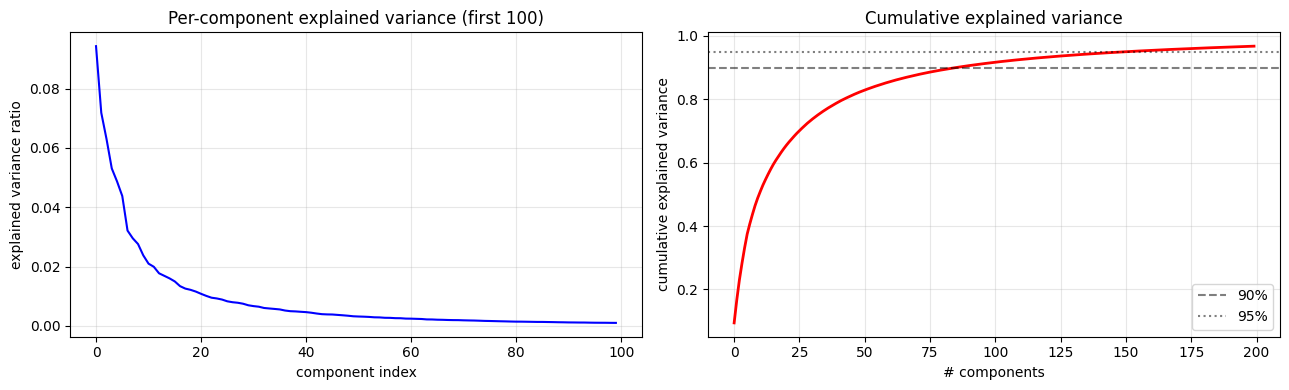

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(explained[:100], 'b-', linewidth=1.5)
axes[0].set_xlabel('component index')
axes[0].set_ylabel('explained variance ratio')
axes[0].set_title('Per-component explained variance (first 100)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cum_explained[:200], 'r-', linewidth=2)
axes[1].axhline(0.9, color='k', linestyle='--', alpha=0.5, label='90%')
axes[1].axhline(0.95, color='k', linestyle=':',  alpha=0.5, label='95%')
axes[1].set_xlabel('# components')
axes[1].set_ylabel('cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 2-D Projection: top-2 principal components

The first two PCs already separate several digit classes.

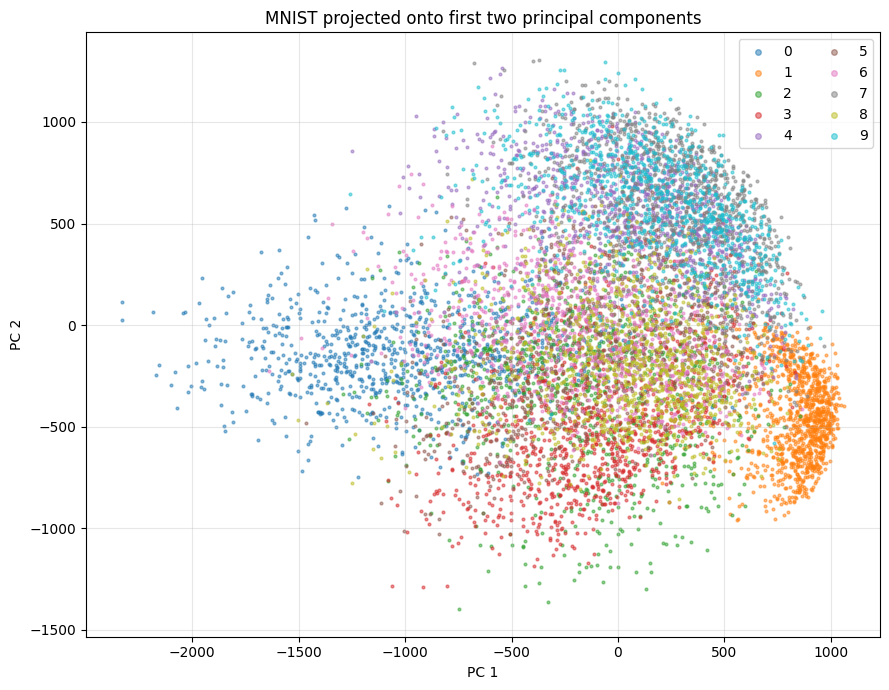

In [21]:
# Projection onto top-2 PCs: scores are columns of U @ diag(S)
PC = U[:, :2] * S[:2]

plt.figure(figsize=(9, 7))
for digit in range(10):
    mask = (y == digit)
    plt.scatter(PC[mask, 0], PC[mask, 1], s=4, alpha=0.5, label=str(digit))
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('MNIST projected onto first two principal components')
plt.legend(markerscale=2, loc='best', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Eigendigits

Each row of $V^\top$ reshaped to $28\times 28$ — the principal directions in image space.
First few capture global brightness/orientation; later ones encode local detail.

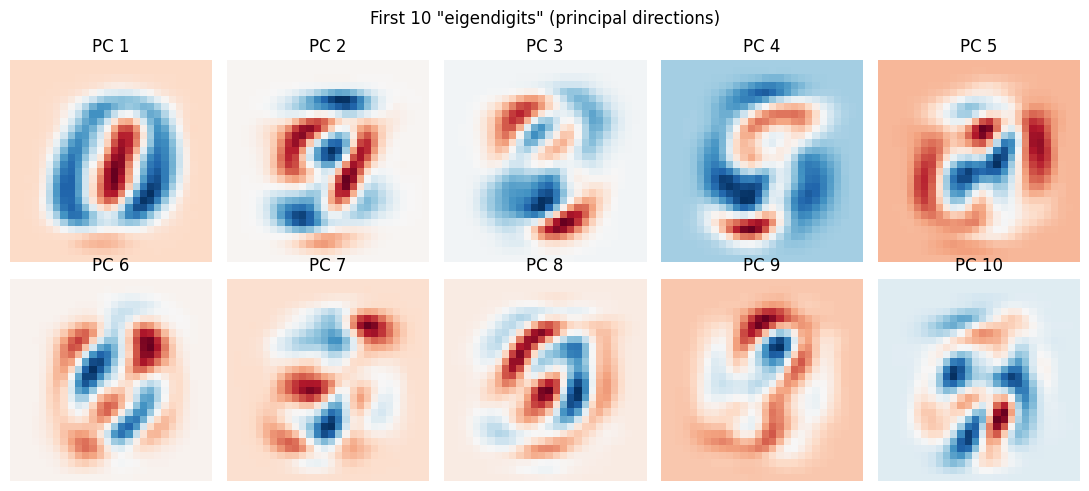

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(Vt[i].reshape(28, 28), cmap='RdBu_r')
    ax.set_title(f'PC {i+1}')
    ax.axis('off')
plt.suptitle('First 10 "eigendigits" (principal directions)')
plt.tight_layout()
plt.show()


## Reconstructing Digits at Various $k$

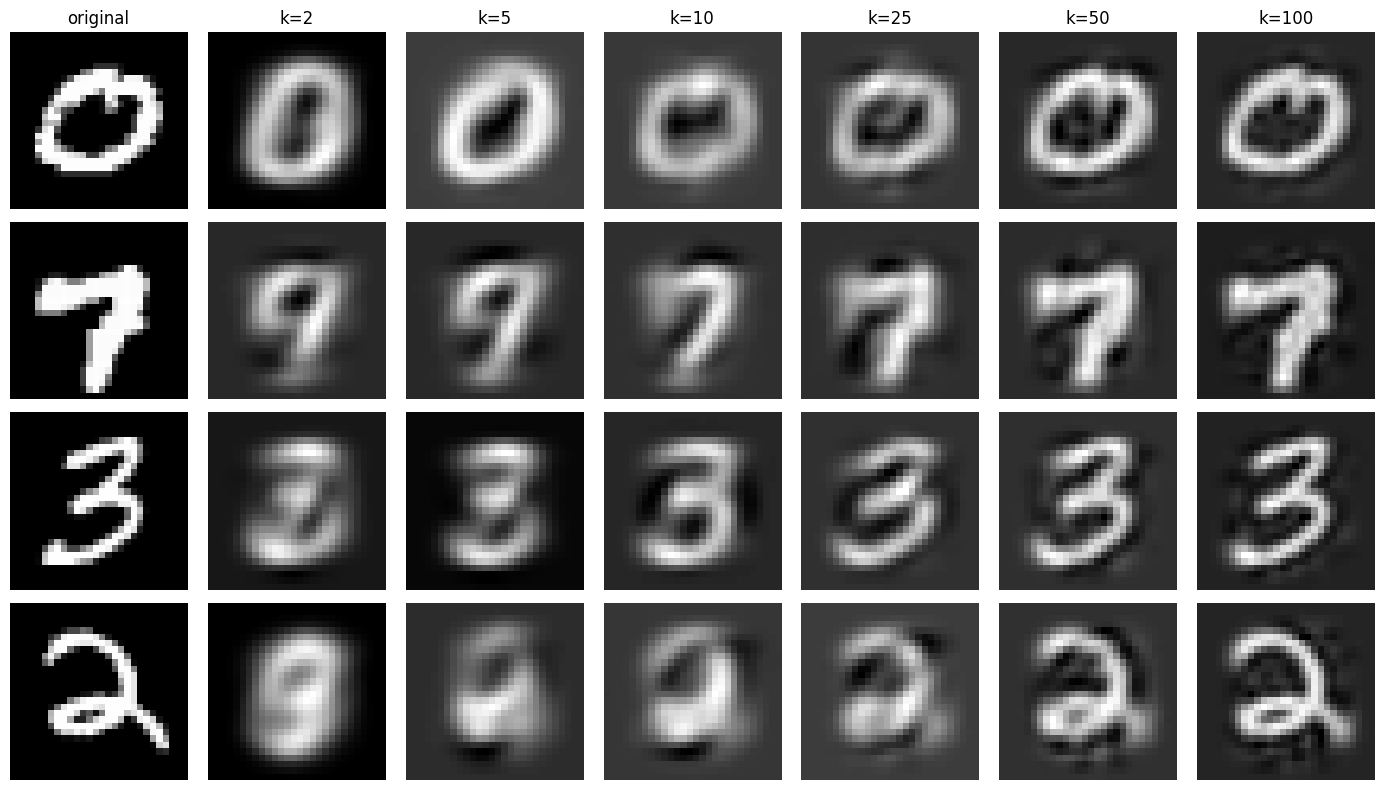

In [23]:
def reconstruct(X_centered, mean, Vt, k):
    "Project to top-k subspace then back; add mean."
    Vk = Vt[:k]                              # (k, 784)
    coeffs = X_centered @ Vk.T               # (n, k)
    return coeffs @ Vk + mean                # (n, 784)

ks = [2, 5, 10, 25, 50, 100]
sample_indices = rng.choice(N, size=4, replace=False)

fig, axes = plt.subplots(len(sample_indices), len(ks) + 1, figsize=(2 * (len(ks)+1), 2 * len(sample_indices)))
for r_, sample_i in enumerate(sample_indices):
    axes[r_, 0].imshow(X[sample_i].reshape(28,28), cmap='gray')
    axes[r_, 0].set_title('original' if r_ == 0 else '')
    axes[r_, 0].axis('off')
    for c_, k in enumerate(ks, start=1):
        rec = reconstruct(Xc[sample_i:sample_i+1], mean_image, Vt, k)
        axes[r_, c_].imshow(rec.reshape(28,28), cmap='gray')
        axes[r_, c_].set_title(f'k={k}' if r_ == 0 else '')
        axes[r_, c_].axis('off')
plt.tight_layout()
plt.show()


## Reconstruction Error vs $k$

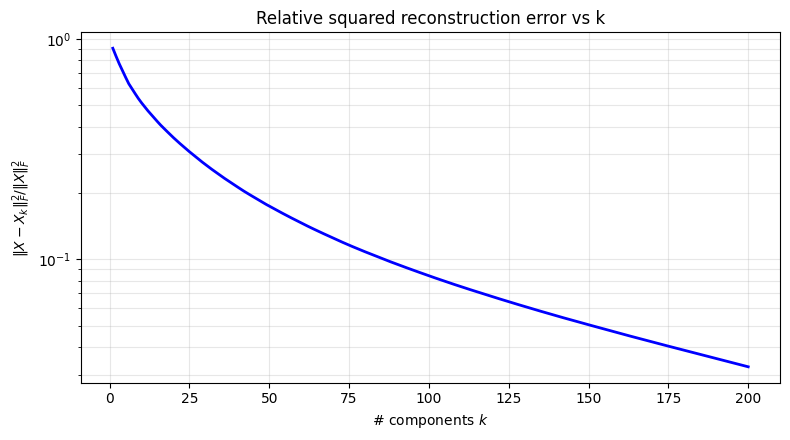

In [24]:
# By Eckart-Young, mean reconstruction error squared = sum of trailing variance
ks_all = np.arange(1, 201)
rel_err_sq = 1 - cum_explained[ks_all - 1]    # fraction of variance NOT captured

plt.figure(figsize=(8, 4.5))
plt.semilogy(ks_all, rel_err_sq, 'b-', linewidth=2)
plt.xlabel('# components $k$')
plt.ylabel(r'$\|X - X_k\|_F^2 / \|X\|_F^2$')
plt.title('Relative squared reconstruction error vs k')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()


## Why is PCA Useful? Demo: **Classification with Far Fewer Features**

We will train a logistic-regression classifier on
- the **full** 784-dimensional pixel vectors, vs.
- **PCA-reduced** $k$-dimensional features, for a range of $k$.

If PCA captures the relevant structure, accuracy should saturate at small $k$ while training time drops sharply. This is the everyday practical payoff of low-rank approximation in machine learning.


In [25]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Scale pixels to [0, 1] -- standard MNIST preprocessing.
# This is what makes LBFGS converge cleanly. Without it, the optimizer
# stalls because raw pixel values (0-255) are badly conditioned.
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# PCA basis: must be fitted on TRAINING data only
mean_train = X_train.mean(axis=0)
Xc_train = X_train - mean_train
Xc_test  = X_test  - mean_train
U_tr, S_tr, Vt_tr = svd(Xc_train, full_matrices=False)

def train_eval(Xtr, Xte, label):
    t0 = time.time()
    clf = LogisticRegression(max_iter=1000)
    clf.fit(Xtr, y_train)
    t = time.time() - t0
    acc = accuracy_score(y_test, clf.predict(Xte))
    print(f"{label:>20s}:  acc = {acc:.4f}   train time = {t:5.2f}s")
    return acc, t

# Baseline: full 784-dim features
full_acc, full_time = train_eval(X_train, X_test, f"full d=784")

ks_clf = [2, 5, 10, 25, 50, 100, 200]
accs, times = [], []
for k in ks_clf:
    Vk = Vt_tr[:k]
    Xtr_k = Xc_train @ Vk.T
    Xte_k = Xc_test  @ Vk.T
    a, t = train_eval(Xtr_k, Xte_k, f"PCA k={k}")
    accs.append(a); times.append(t)


          full d=784:  acc = 0.8995   train time =  1.97s
             PCA k=2:  acc = 0.4385   train time =  0.12s
             PCA k=5:  acc = 0.6720   train time =  0.16s
            PCA k=10:  acc = 0.8040   train time =  0.16s
            PCA k=25:  acc = 0.8810   train time =  0.18s
            PCA k=50:  acc = 0.9030   train time =  0.21s
           PCA k=100:  acc = 0.9000   train time =  0.24s
           PCA k=200:  acc = 0.9030   train time =  0.57s


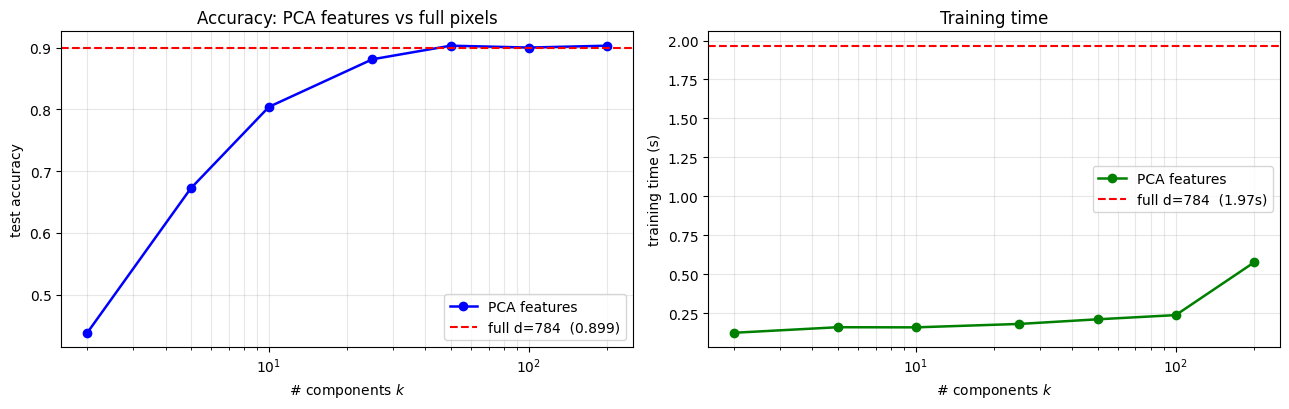

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(ks_clf, accs, 'b-o', linewidth=1.8, markersize=6, label='PCA features')
axes[0].axhline(full_acc, color='r', linestyle='--', label=f'full d=784  ({full_acc:.3f})')
axes[0].set_xscale('log')
axes[0].set_xlabel('# components $k$')
axes[0].set_ylabel('test accuracy')
axes[0].set_title('Accuracy: PCA features vs full pixels')
axes[0].grid(alpha=0.3, which='both'); axes[0].legend()

axes[1].plot(ks_clf, times, 'g-o', linewidth=1.8, markersize=6, label='PCA features')
axes[1].axhline(full_time, color='r', linestyle='--', label=f'full d=784  ({full_time:.2f}s)')
axes[1].set_xscale('log')
axes[1].set_xlabel('# components $k$')
axes[1].set_ylabel('training time (s)')
axes[1].set_title('Training time')
axes[1].grid(alpha=0.3, which='both'); axes[1].legend()

plt.tight_layout()
plt.show()


###### **Takeaway.** PCA gives us a much smaller feature representation (e.g., 50 numbers per image instead of 784) while preserving classification accuracy. Training is faster, models are smaller, and downstream pipelines are cheaper — this is the *practical* payoff of low-rank structure.

---

## Conclusions

1. MNIST has strong low-rank structure: ~50 components capture >85% of variance.
2. The first 2 PCs already give partial class separation; supervised methods (LDA) do better but PCA is unsupervised.
3. Eigendigits visualise what the top variance directions actually look like.
4. Reconstruction quality saturates quickly — diminishing returns past $k \approx 100$.
